# Figure S16: FA/MD Software Comparison (Batch, Age, Quality Effects)

Three-row by two-column figure with FA and MD panels paired by effect type. Columns show unharmonized batch effects, age effects across bundles, and preprocessed dMRI-contrast quality effects, with one violin per software.


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS16/S16_fa_md_software_comparison_batch_age_quality_violin.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS16/S16_fa_md_software_comparison_batch_age_quality_violin.png



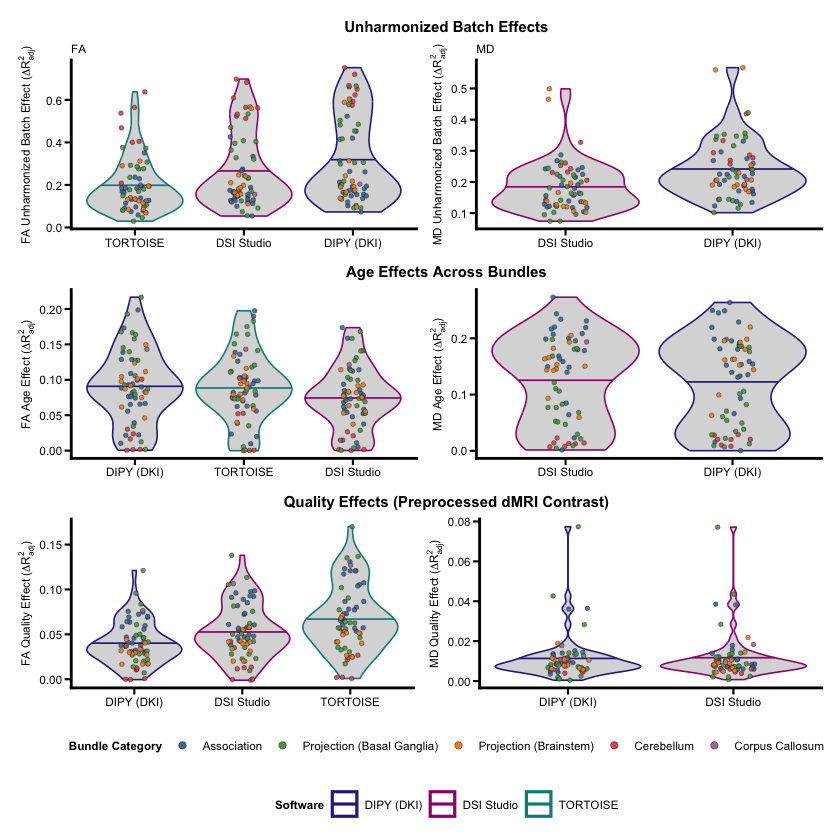

In [ ]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(fs)
  library(jsonlite)
  library(scales)
  library(patchwork)
})

find_config_path <- function() {
  env_path <- Sys.getenv("CONFIG_PATH", unset = "")
  if (nzchar(env_path) && file.exists(env_path)) {
    return(normalizePath(env_path, winslash = "/", mustWork = TRUE))
  }

  d <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
  repeat {
    cand <- file.path(d, "config.json")
    if (file.exists(cand)) {
      return(normalizePath(cand, winslash = "/", mustWork = TRUE))
    }
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }

  stop("Could not locate config.json. Set CONFIG_PATH or launch Jupyter from within the project tree.")
}

config_path <- find_config_path()
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)

plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure_s16_dir <- fs::path(project_root, "figures", "Supplement", "FigureS16")
fs::dir_create(figure_s16_dir, recurse = TRUE)

target_metrics <- c("DKI_fa", "GQI_fa", "MAPMRI_fa", "DKI_md", "GQI_md")
software_order <- c("DKI", "GQI", "MAPMRI")

# Distinct from vendor and bundle palettes
software_colors <- c(
  "DKI" = "#2E2A8F",
  "GQI" = "#A11D7E",
  "MAPMRI" = "#008B8B"
)
software_labels <- c(
  "DKI" = "DIPY (DKI)",
  "GQI" = "DSI Studio",
  "MAPMRI" = "TORTOISE"
)

metric_to_software <- function(metric) {
  case_when(
    str_starts(metric, "DKI_") ~ "DKI",
    str_starts(metric, "GQI_") ~ "GQI",
    str_starts(metric, "MAPMRI_") ~ "MAPMRI",
    TRUE ~ NA_character_
  )
}

metric_to_measure <- function(metric) {
  case_when(
    str_detect(metric, "_fa$") ~ "FA",
    str_detect(metric, "_md$") ~ "MD",
    TRUE ~ NA_character_
  )
}

pretty_bundle_category <- function(x) {
  recode(x, !!!category_label_map)
}

batch_file <- fs::path(project_root, "data", "batch_effects", "batch_effects_all_outputs.rds")
age_file <- fs::path(project_root, "data", "age_effects", "age_effects_all_outputs.rds")
quality_file <- fs::path(project_root, "data", "quality_effects", "quality_effects_all_outputs.rds")

if (!file.exists(batch_file)) stop("Missing batch effects file: ", batch_file)
if (!file.exists(age_file)) stop("Missing age effects file: ", age_file)
if (!file.exists(quality_file)) stop("Missing quality effects file: ", quality_file)

df_batch_all <- readRDS(batch_file)
df_age_all <- readRDS(age_file)
df_quality_all <- readRDS(quality_file)

required_batch <- c("output_type", "source", "qc_covariate", "metric", "bundle", "bundle_category", "effect_size")
required_age <- c("output_type", "source", "scanner_manufacturer", "qc_metric", "metric", "bundle", "bundle_category", "age_effect_size")
required_quality <- c("output_type", "source", "qc_metric", "metric", "bundle", "bundle_category", "qc_effect_size")

if (!all(required_batch %in% names(df_batch_all))) {
  stop("Batch effects file missing required columns: ", paste(setdiff(required_batch, names(df_batch_all)), collapse = ", "))
}
if (!all(required_age %in% names(df_age_all))) {
  stop("Age effects file missing required columns: ", paste(setdiff(required_age, names(df_age_all)), collapse = ", "))
}
if (!all(required_quality %in% names(df_quality_all))) {
  stop("Quality effects file missing required columns: ", paste(setdiff(required_quality, names(df_quality_all)), collapse = ", "))
}

df_batch <- df_batch_all %>%
  filter(
    output_type == "batch_effects",
    source == "raw",
    qc_covariate == "no_quality",
    metric %in% target_metrics,
    !is.na(bundle), !is.na(bundle_category), !is.na(effect_size)
  ) %>%
  transmute(
    metric,
    software = metric_to_software(metric),
    measure = metric_to_measure(metric),
    bundle,
    bundle_category_pretty = pretty_bundle_category(bundle_category),
    value = as.numeric(effect_size)
  ) %>%
  filter(!is.na(software), !is.na(measure), !is.na(bundle_category_pretty)) %>%
  mutate(bundle_category_pretty = factor(bundle_category_pretty, levels = bundle_category_order_pretty))

df_age <- df_age_all %>%
  filter(
    output_type == "pooled",
    source == "harmonized",
    scanner_manufacturer == "all",
    qc_metric == "no_quality",
    metric %in% target_metrics,
    !is.na(bundle), !is.na(bundle_category), !is.na(age_effect_size)
  ) %>%
  transmute(
    metric,
    software = metric_to_software(metric),
    measure = metric_to_measure(metric),
    bundle,
    bundle_category_pretty = pretty_bundle_category(bundle_category),
    value = as.numeric(age_effect_size)
  ) %>%
  filter(!is.na(software), !is.na(measure), !is.na(bundle_category_pretty)) %>%
  mutate(bundle_category_pretty = factor(bundle_category_pretty, levels = bundle_category_order_pretty))

df_quality <- df_quality_all %>%
  filter(
    output_type == "non_vendorwise_pairwise",
    source == "harmonized",
    qc_metric == "t1post_dwi_contrast",
    metric %in% target_metrics,
    !is.na(bundle), !is.na(bundle_category), !is.na(qc_effect_size)
  ) %>%
  transmute(
    metric,
    software = metric_to_software(metric),
    measure = metric_to_measure(metric),
    bundle,
    bundle_category_pretty = pretty_bundle_category(bundle_category),
    value = as.numeric(qc_effect_size)
  ) %>%
  filter(!is.na(software), !is.na(measure), !is.na(bundle_category_pretty)) %>%
  mutate(bundle_category_pretty = factor(bundle_category_pretty, levels = bundle_category_order_pretty))

if (nrow(df_batch) == 0) stop("No unharmonized batch-effect rows found for target FA/MD metrics.")
if (nrow(df_age) == 0) stop("No age-effect rows found for target FA/MD metrics.")
if (nrow(df_quality) == 0) stop("No quality-effect rows found for target FA/MD metrics.")

panel_theme <- function() {
  make_theme_pub(
    style = plot_style,
    legend_position = "right",
    axis_title_pt = 7,
    axis_text_pt = 7,
    plot_title_pt = 8,
    legend_title_pt = 7,
    legend_text_pt = 7,
    base_size_pt = 7
  ) +
    theme(
      text = element_text(family = font_family_use),
      panel.grid.major.x = element_blank(),
      axis.text.x = element_text(angle = 0, hjust = 0.5),
      plot.title = element_text(face = "bold", hjust = 0.5),
      plot.margin = margin(4, 4, 4, 4)
    )
}

measure_software_levels <- function(measure_name) {
  if (identical(measure_name, "MD")) c("DKI", "GQI") else software_order
}

order_software_by_effect <- function(dat, levs, order_direction = c("desc", "asc")) {
  order_direction <- match.arg(order_direction)
  ord_tbl <- dat %>%
    group_by(software) %>%
    summarise(mean_effect = mean(value, na.rm = TRUE), .groups = "drop")

  ord <- if (identical(order_direction, "desc")) {
    ord_tbl %>% arrange(desc(mean_effect)) %>% pull(software) %>% as.character()
  } else {
    ord_tbl %>% arrange(mean_effect) %>% pull(software) %>% as.character()
  }

  levs <- as.character(levs)
  c(ord, setdiff(levs, ord))
}

build_mean_segments <- function(dat) {
  dat2 <- dat %>% mutate(software_idx = x_pos)

  mean_df <- dat2 %>%
    group_by(software, software_idx) %>%
    summarise(mean_effect = mean(value, na.rm = TRUE), .groups = "drop")

  vg <- ggplot_build(
    ggplot(dat2, aes(x = software_idx, y = value, group = software)) +
      geom_violin(width = 0.88, trim = TRUE, scale = "width")
  )$data[[1]] %>%
    mutate(software_idx = as.numeric(group))

  mean_df %>%
    mutate(
      width_frac = purrr::map2_dbl(software_idx, mean_effect, function(idx, mean_val) {
        this_geom <- vg %>% filter(software_idx == idx)
        if (nrow(this_geom) == 0) return(0)
        out <- stats::approx(
          x = this_geom$y,
          y = this_geom$violinwidth,
          xout = mean_val,
          rule = 2
        )$y
        if (!is.finite(out)) 0 else as.numeric(out)
      }),
      half_width = purrr::map_dbl(software_idx, function(idx) {
        this_geom <- vg %>% filter(software_idx == idx)
        if (nrow(this_geom) == 0) return(0)
        max(this_geom$xmax - this_geom$x, na.rm = TRUE)
      }) * width_frac,
      x_start = software_idx - half_width,
      x_end = software_idx + half_width
    )
}

make_effect_panel <- function(dat_in, measure_name, y_lab, col_title = NULL,
                              order_direction = c("desc", "asc"), show_legends = FALSE) {
  order_direction <- match.arg(order_direction)
  levs <- measure_software_levels(measure_name)
  dat <- dat_in %>%
    filter(measure == measure_name, software %in% levs) %>%
    mutate(software = factor(software, levels = levs))

  panel_order <- order_software_by_effect(dat, levs, order_direction = order_direction)
  dat <- dat %>%
    mutate(
      software = factor(software, levels = panel_order),
      x_pos = match(as.character(software), panel_order)
    )
  seg_df <- build_mean_segments(dat)

  x_breaks <- seq_along(panel_order)
  x_labels <- unname(software_labels[panel_order])

  p <- ggplot(dat, aes(x = x_pos, y = value)) +
    geom_violin(
      aes(group = software, color = software),
      linewidth = 0.45,
      width = 0.88,
      trim = TRUE,
      scale = "width",
      fill = alpha("grey70", 0.50),
      na.rm = TRUE
    ) +
    geom_segment(
      data = seg_df,
      aes(x = x_start, xend = x_end, y = mean_effect, yend = mean_effect, color = software),
      inherit.aes = FALSE,
      linewidth = 0.48
    ) +
    geom_jitter(
      aes(fill = bundle_category_pretty),
      shape = 21,
      color = "black",
      stroke = 0.15,
      width = 0.13,
      height = 0,
      size = 1.2,
      alpha = 0.9,
      na.rm = TRUE
    ) +
    scale_x_continuous(breaks = x_breaks, labels = x_labels) +
    scale_color_manual(
      values = software_colors,
      limits = software_order,
      breaks = software_order,
      labels = software_labels[software_order],
      name = "Software",
      drop = FALSE
    ) +
    scale_fill_manual(
      values = bundle_color_pretty,
      name = "Bundle Category",
      drop = FALSE
    ) +
    labs(
      title = col_title,
      x = NULL,
      y = y_lab
    ) +
    panel_theme()

  if (!show_legends) {
    p <- p + guides(color = "none", fill = "none")
  } else {
    p <- p + guides(
      fill = guide_legend(order = 1, override.aes = list(shape = 21, size = 2, color = "black", alpha = 1)),
      color = guide_legend(order = 2, override.aes = list(fill = NA, linewidth = 0.9))
    )
  }

  p
}

# Batch and quality: lowest -> highest; Age: highest -> lowest
p_fa_batch <- make_effect_panel(
  df_batch,
  "FA",
  expression("FA Unharmonized Batch Effect (" * Delta * R[adj]^2 * ")"),
  NULL,
  order_direction = "asc",
  show_legends = FALSE
)
p_fa_age <- make_effect_panel(
  df_age,
  "FA",
  expression("FA Age Effect (" * Delta * R[adj]^2 * ")"),
  NULL,
  order_direction = "desc",
  show_legends = FALSE
)
p_fa_qc <- make_effect_panel(
  df_quality,
  "FA",
  expression("FA Quality Effect (" * Delta * R[adj]^2 * ")"),
  NULL,
  order_direction = "asc",
  show_legends = TRUE
)

p_md_batch <- make_effect_panel(
  df_batch,
  "MD",
  expression("MD Unharmonized Batch Effect (" * Delta * R[adj]^2 * ")"),
  NULL,
  order_direction = "asc",
  show_legends = FALSE
)
p_md_age <- make_effect_panel(
  df_age,
  "MD",
  expression("MD Age Effect (" * Delta * R[adj]^2 * ")"),
  NULL,
  order_direction = "desc",
  show_legends = FALSE
)
p_md_qc <- make_effect_panel(
  df_quality,
  "MD",
  expression("MD Quality Effect (" * Delta * R[adj]^2 * ")"),
  NULL,
  order_direction = "asc",
  show_legends = FALSE
)

p_fa_batch <- p_fa_batch + labs(subtitle = "FA")
p_md_batch <- p_md_batch + labs(subtitle = "MD")

title_strip <- function(title_text) {
  ggplot() +
    theme_void() +
    labs(title = title_text) +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold", family = font_family_use, size = 9),
      plot.margin = margin(0, 4, 0, 4)
    )
}

t_batch <- title_strip("Unharmonized Batch Effects")
t_age <- title_strip("Age Effects Across Bundles")
t_qc <- title_strip("Quality Effects (Preprocessed dMRI Contrast)")

p_s16 <- (
  patchwork::wrap_elements(t_batch)
) / (
  p_fa_batch | p_md_batch
) / (
  patchwork::wrap_elements(t_age)
) / (
  p_fa_age | p_md_age
) / (
  patchwork::wrap_elements(t_qc)
) / (
  p_fa_qc | p_md_qc
) + patchwork::plot_layout(guides = "collect", heights = c(0.06, 1, 0.06, 1, 0.06, 1))

p_s16 <- p_s16 & theme(
  legend.position = "bottom",
  legend.box = "vertical",
  plot.title = element_text(hjust = 0.5, face = "bold")
)

p_s16

save_plot_outputs(
  plot_obj = p_s16,
  stub = "S16_fa_md_software_comparison_batch_age_quality_violin",
  out_dir = figure_s16_dir,
  width_in = 7,
  height_in = 8,
  allow_sans_fallback = TRUE
)


